In [61]:
!pip install qiskit

In [62]:
import math
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, Operator

In [63]:

def next_power_of_2(n):
    return 1 if n == 0 else 2 ** math.ceil(math.log2(n))


def haar_matrix_builder(n):
    """Build n×n orthonormal Haar wavelet matrix."""
    if n == 1:
        return np.array([[1.0]])
    if n == 2:
        return np.array([[1, 1], [1, -1]]) / math.sqrt(2)
    half = n // 2
    H_prev = haar_matrix_builder(half)
    H = np.zeros((n, n))
    H[:half, :] = np.kron(H_prev, np.array([1, 1])) / math.sqrt(2)
    for i in range(half):
        H[half + i, 2 * i]     =  1.0 / math.sqrt(2)
        H[half + i, 2 * i + 1] = -1.0 / math.sqrt(2)
    return H


def haar_transform_2d_classical(X):
    H, W = X.shape
    Hm = haar_matrix_builder(H)
    Wm = haar_matrix_builder(W)
    return Hm @ X @ Wm.T


def get_statevector_no_measure(qc):
    """Get statevector from a circuit, stripping measurements if present."""
    qc_copy = qc.copy()
    qc_copy.remove_final_measurements(inplace=True)
    return Statevector.from_instruction(qc_copy).data


In [64]:


# =====================================================================
# Implementation 1: ORIGINAL (your circuit)
# =====================================================================
# Structure analysis:
#   Row qubits: q[0], q[1]  (W dimension, 2 qubits → 4 columns)
#   Col qubits: q[2], q[3]  (H dimension, 2 qubits → 4 rows)
#
#   For columns (q[0:2]):
#     SWAP(q0,q1) → H(q1) → X(q1) → CH(q1,q0) → X(q1)
#   For rows (q[2:4]):
#     SWAP(q2,q3) → H(q3) → X(q3) → CH(q3,q2) → X(q3)
#
#   The pattern is: permute → Hadamard on MSB → controlled-H on LSB
#   conditioned on MSB=|0⟩ (the X-CH-X trick implements "controlled
#   on |0⟩" behaviour).
# =====================================================================

def build_original(amps):
    """Your original SWAP+H+X+CH circuit for 4×4 = 4 qubits."""
    q = QuantumRegister(4, "q")
    qc = QuantumCircuit(q)
    qc.initialize(amps, q)

    # Column transform (q[0], q[1])
    qc.swap(q[0], q[1])
    qc.h(q[1])
    qc.x(q[1])
    qc.ch(q[1], q[0])
    qc.x(q[1])

    # Row transform (q[2], q[3])
    qc.swap(q[2], q[3])
    qc.h(q[3])
    qc.x(q[3])
    qc.ch(q[3], q[2])
    qc.x(q[3])

    return qc


In [65]:

# =====================================================================
# Implementation 2: FIJANY–WILLIAMS (butterfly + perfect-shuffle)
# =====================================================================
# From: Fijany & Williams (quant-ph/9809004)
#
# The n-point Haar factors as:
#     H_n = (H_{n/2} ⊕ I_{n/2}) · B_n · Π_n
# where Π_n = perfect shuffle, B_n = butterfly (pairs of H2 kernels).
#
# For 2 qubits (4-point):
#   Level 1: shuffle all 2 qubits → butterfly on LSB
#   Level 2: shuffle bottom 1 qubit (no-op) → butterfly on LSB
#
# Butterfly = H gate + Z gate on LSB (gives [1,1],[1,-1]/√2 kernel)
# Perfect shuffle on k qubits = cascade of (k-1) SWAPs
# =====================================================================

def build_fijany_williams(amps):
    """Fijany–Williams decomposition: butterfly + perfect-shuffle."""
    q = QuantumRegister(4, "q")
    qc = QuantumCircuit(q)
    qc.initialize(amps, q)

    def apply_fw(qubits):
        n = len(qubits)
        for k in range(n, 0, -1):
            sub = qubits[:k]
            # Perfect shuffle: cyclic left-shift via SWAP cascade
            for i in range(len(sub) - 1):
                qc.swap(sub[i], sub[i + 1])
            # Butterfly: H + Z on LSB
            qc.h(sub[0])
            qc.z(sub[0])

    # Column qubits
    apply_fw([q[0], q[1]])
    # Row qubits
    apply_fw([q[2], q[3]])

    return qc


In [66]:

# =====================================================================
# Implementation 3: PYRAMIDAL (Hoyer-style multi-controlled H)
# =====================================================================
# From: Hoyer (quant-ph/9702028)
#
# At each level j, apply H to qubit j controlled on all higher
# qubits being |0⟩.  The "controlled on |0⟩" is done via
# X-gates wrapping the controls (same trick as your original).
#
# For 2 qubits:
#   Level 0: H(q0) controlled on q1=|0⟩  → X(q1), CH(q1,q0), X(q1)
#   Level 1: H(q1) unconditionally
# =====================================================================

def build_pyramidal(amps):
    """Pyramidal / Hoyer: multi-controlled H, level by level."""
    q = QuantumRegister(4, "q")
    qc = QuantumCircuit(q)
    qc.initialize(amps, q)

    def apply_pyramidal(qubits):
        n = len(qubits)
        for j in range(n):
            target = qubits[j]
            controls = qubits[j + 1:]
            # Apply H to target, controlled on all controls being |0⟩
            for c in controls:
                qc.x(c)
            if len(controls) == 0:
                qc.h(target)
            elif len(controls) == 1:
                qc.ch(controls[0], target)
            else:
                # For >1 controls, use multi-controlled H
                # MCH = X-flipped controls + multi-controlled gate
                from qiskit.circuit.library import HGate
                qc.append(HGate().control(len(controls)), controls + [target])
            for c in controls:
                qc.x(c)

    # Column qubits
    apply_pyramidal([q[0], q[1]])
    # Row qubits
    apply_pyramidal([q[2], q[3]])

    return qc


In [67]:

# =====================================================================
# Implementation 4: DIRECT UNITARY (Haar matrix → transpiled gates)
# =====================================================================
# Build the exact Haar unitary matrix, apply it as an Operator, then
# transpile to native gates (cx, u3, etc.) to get a fair gate count.
# This is the "gold standard" — exact Haar, but the transpiler decides
# the circuit structure.
# =====================================================================

def build_direct_unitary(amps):
    """Build exact Haar unitary, transpile to native gates."""
    q = QuantumRegister(4, "q")
    qc = QuantumCircuit(q)
    qc.initialize(amps, q)

    H2 = haar_matrix_builder(4)  # 4×4 Haar matrix

    # Apply Haar on column qubits
    qc.append(Operator(H2), [q[0], q[1]])
    # Apply Haar on row qubits
    qc.append(Operator(H2), [q[2], q[3]])

    # Transpile to native gates for fair comparison
    qc_transpiled = transpile(qc, basis_gates=['cx', 'u3', 'u2', 'u1', 'id'],
                              optimization_level=3)
    return qc_transpiled



# COMPARISON UNDER PAULI NOISE

In [68]:
# apply X pauli matrix
def apply_x_to_statevector(sv: np.ndarray, n_qubits: int, q: int) -> np.ndarray:
    psi = sv.reshape([2] * n_qubits)
    psi = np.swapaxes(psi, q, 0)
    psi = psi[::-1, ...] # reverse order of amplitudes to apply X gate
    psi = np.swapaxes(psi, 0, q)
    return psi.reshape(-1)

# apply Z pauli matrix
def apply_z_to_statevector(sv: np.ndarray, n_qubits: int, q: int) -> np.ndarray:
    psi = sv.reshape([2] * n_qubits)
    psi = np.swapaxes(psi, q, 0)
    psi[1, ...] *= -1 # multiply amplitudes of 1 states by -1
    psi = np.swapaxes(psi, 0, q)
    return psi.reshape(-1)

# apply random pauli gates to the circuit
def apply_local_pauli_noise(sv: np.ndarray, n_qubits: int, p: float, rng=None) -> np.ndarray:
    # if no seed is given use random seed
    if rng is None:
        rng = np.random.default_rng()

    # takes copy of statevector
    out = sv.copy()

    # randomly applies X, Y, Z paulis to qubit
    # higher p means higher error
    for q in range(n_qubits):
        r = rng.random() # random float from 0 to 1

        if r < (1 - p): # 1-p chance of applying identity
            continue

        elif r < (1 - p) + p/3: # p/3 chance of applying X
            out = apply_x_to_statevector(out, n_qubits, q)

        elif r < (1 - p) + 2*p/3: # p/3 chance of applying Y
            # applies Y pauli implicitly since Y=iXZ
            out = apply_z_to_statevector(out, n_qubits, q)
            out = apply_x_to_statevector(out, n_qubits, q)
            out = 1j * out

        else: # p/3 chance of applying Z
            out = apply_z_to_statevector(out, n_qubits, q)

    return out

# noise function
def haar_noise(sv_ideal, H_pad, W_pad, n_qubits, p=0.01, trials=100, seed=0):
    rng = np.random.default_rng(seed)
    Ys = []

    # runs multiple trials of noise to avg out at the end
    for _ in range(trials):
        sv_noisy = apply_local_pauli_noise(sv_ideal, n_qubits, p, rng=rng)
        Ys.append(sv_noisy.reshape(H_pad, W_pad))

    # take mean and standard deviation of the noisy Haar transformed images
    Ys = np.stack(Ys, axis=0)
    mean_Y = Ys.mean(axis=0)
    std_Y = np.abs(Ys).std(axis=0)

    return mean_Y, std_Y

def compare_all(X, p_values=(0.0, 0.005, 0.01, 0.02, 0.05, 0.1),
                trials=300, seed=42):
    """
    Compare all 4 implementations on input X (shape 4×4).
    Uses the user's Pauli noise model (apply_local_pauli_noise / haar_noise).
    """
    H, W = X.shape
    n_qubits = 4  # 2 col + 2 row for 4×4

    psi = X.flatten()
    norm = np.linalg.norm(psi)
    amps = psi / norm

    builders = {
        "Original (SWAP+H+CH)":    build_original,
        "Fijany-Williams (H+Z)":   build_fijany_williams,
        "Pyramidal (Hoyer)":       build_pyramidal,
        "Direct Unitary (transpiled)": build_direct_unitary,
    }

    # ── Build circuits & get ideal statevectors ──
    circuits = {}
    ideal_svs = {}
    gate_info = {}

    print("=" * 72)
    print("CIRCUIT INFORMATION")
    print("=" * 72)
    print(f"  {'Implementation':<35s} {'Gates':>6s} {'Depth':>6s} {'CX':>5s}")
    print(f"  {'─' * 35} {'─' * 6} {'─' * 6} {'─' * 5}")

    for name, builder in builders.items():
        qc = builder(amps)
        circuits[name] = qc
        sv = get_statevector_no_measure(qc)
        ideal_svs[name] = sv

        # Transpile for gate count comparison
        qc_t = transpile(qc, basis_gates=['cx', 'u3', 'u2', 'u1', 'id'],
                         optimization_level=3)
        n_cx = qc_t.count_ops().get('cx', 0)
        gate_info[name] = {
            "raw_gates": qc.size(),
            "transpiled_gates": qc_t.size(),
            "depth": qc_t.depth(),
            "cx": n_cx,
        }
        print(f"  {name:<35s} {qc_t.size():>6d} {qc_t.depth():>6d} {n_cx:>5d}")

    # ── Classical reference ──
    Yc = haar_transform_2d_classical(X) / norm
    Yc_flat = Yc.flatten()

    # ── Noiseless fidelity vs classical ──
    print(f"\n{'=' * 72}")
    print("NOISELESS FIDELITY vs CLASSICAL HAAR")
    print(f"{'=' * 72}")
    for name in builders:
        sv = ideal_svs[name]
        Yq_flat = sv.real.flatten()
        na = np.linalg.norm(Yq_flat)
        nb = np.linalg.norm(Yc_flat)
        fid = np.abs(np.dot(Yq_flat / na, Yc_flat / nb)) ** 2 if na > 0 and nb > 0 else 0
        print(f"  {name:<35s}  fidelity = {fid:.8f}")

    # ── Noiseless pairwise fidelity ──
    print(f"\n{'=' * 72}")
    print("NOISELESS PAIRWISE FIDELITY (quantum vs quantum)")
    print(f"{'=' * 72}")
    names = list(builders.keys())
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            sv_a = ideal_svs[names[i]]
            sv_b = ideal_svs[names[j]]
            fid = np.abs(np.dot(sv_a.conj() / np.linalg.norm(sv_a),
                                sv_b / np.linalg.norm(sv_b))) ** 2
            print(f"  {names[i]:30s} ↔ {names[j]:30s}  {fid:.8f}")

    # ── Pauli noise sweep ──
    print(f"\n{'=' * 72}")
    print(f"PAULI NOISE COMPARISON  (trials={trials})")
    print(f"{'=' * 72}")

    results = {name: {"p": [], "mse_mean": [], "mse_std": [],
                       "fid_mean": [], "fid_std": []}
               for name in builders}

    for p in p_values:
        print(f"\n  p = {p:.4f}")
        print(f"    {'Implementation':<35s} {'MSE':>12s} {'Fidelity':>12s}")
        print(f"    {'─' * 35} {'─' * 12} {'─' * 12}")

        for name in builders:
            sv_ideal = ideal_svs[name]

            if p == 0.0:
                mses = [0.0]
                fids = [1.0]
            else:
                rng = np.random.default_rng(seed)
                mses = []
                fids = []
                for _ in range(trials):
                    sv_noisy = apply_local_pauli_noise(sv_ideal, n_qubits, p, rng=rng)
                    mses.append(np.mean(np.abs(sv_noisy - sv_ideal) ** 2))
                    inner = np.dot(sv_noisy.conj(), sv_ideal)
                    fids.append((np.abs(inner) ** 2).real)

            results[name]["p"].append(p)
            results[name]["mse_mean"].append(np.mean(mses))
            results[name]["mse_std"].append(np.std(mses))
            results[name]["fid_mean"].append(np.mean(fids))
            results[name]["fid_std"].append(np.std(fids))

            print(f"    {name:<35s} {np.mean(mses):>10.6f}±{np.std(mses):.4f}"
                  f"  {np.mean(fids):>10.6f}±{np.std(fids):.4f}")

    # ══════════════════════════════════════════════════════════════════
    # PLOTS
    # ══════════════════════════════════════════════════════════════════
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
    markers = ['o', 's', '^', 'D']

    # ── Plot 1: Metrics ──
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("Quantum Haar Wavelet — Pauli Noise Robustness (4×4 input)",
                 fontsize=14, fontweight='bold')

    # MSE
    ax = axes[0]
    for i, name in enumerate(builders):
        r = results[name]
        pp = [v for v in r["p"] if v > 0]
        mm = [r["mse_mean"][j] for j, v in enumerate(r["p"]) if v > 0]
        ss = [r["mse_std"][j] for j, v in enumerate(r["p"]) if v > 0]
        ax.errorbar(pp, mm, yerr=ss, label=name, marker=markers[i],
                    capsize=3, color=colors[i], linewidth=2)
    ax.set_xlabel("Noise probability p", fontsize=11)
    ax.set_ylabel("MSE (vs. noiseless ideal)", fontsize=11)
    ax.set_title("Mean Squared Error")
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)

    # Fidelity
    ax = axes[1]
    for i, name in enumerate(builders):
        r = results[name]
        ax.errorbar(r["p"], r["fid_mean"], yerr=r["fid_std"],
                    label=name, marker=markers[i], capsize=3,
                    color=colors[i], linewidth=2)
    ax.set_xlabel("Noise probability p", fontsize=11)
    ax.set_ylabel("Fidelity |⟨ψ_ideal|ψ_noisy⟩|²", fontsize=11)
    ax.set_title("State Fidelity")
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(alpha=0.3)

    # Gate count (transpiled)
    ax = axes[2]
    names_list = list(builders.keys())
    cx_counts = [gate_info[n]["cx"] for n in names_list]
    total_gates = [gate_info[n]["transpiled_gates"] for n in names_list]
    depths = [gate_info[n]["depth"] for n in names_list]

    x_pos = np.arange(len(names_list))
    w = 0.25
    bars1 = ax.bar(x_pos - w, total_gates, w, label='Total gates', color=colors, alpha=0.7)
    bars2 = ax.bar(x_pos, cx_counts, w, label='CX gates', color=colors, alpha=1.0)
    bars3 = ax.bar(x_pos + w, depths, w, label='Depth', color=colors, alpha=0.4)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([n.split('(')[0].strip() for n in names_list],
                       rotation=15, ha='right', fontsize=8)
    ax.set_ylabel("Count")
    ax.set_title("Circuit Complexity (transpiled)")
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Plot 2: Noiseless transform outputs ──
    fig, axes = plt.subplots(2, 5, figsize=(24, 9))
    fig.suptitle("Transform Outputs — Noiseless", fontsize=14, fontweight='bold')

    # Show input
    im0 = axes[0, 0].imshow(X, cmap='gray', vmin=0, vmax=1, aspect='auto')
    axes[0, 0].set_title("Input X", fontsize=10)
    axes[0, 0].axis('off')
    fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04, label='Pixel value')

    im1 = axes[1, 0].imshow(np.abs(Yc * norm), cmap='hot', aspect='auto')
    axes[1, 0].set_title("Classical Haar", fontsize=10)
    axes[1, 0].axis('off')
    fig.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.04, label='|Coefficient|')

    for i, name in enumerate(builders):
        sv = ideal_svs[name]
        Y = sv.reshape(H, W)
        im_top = axes[0, i + 1].imshow(np.abs(Y) * norm, cmap='hot', aspect='auto')
        axes[0, i + 1].set_title(name.split('(')[0].strip(), fontsize=9)
        axes[0, i + 1].axis('off')
        fig.colorbar(im_top, ax=axes[0, i + 1], fraction=0.046, pad=0.04,
                     label='|Coefficient|')

        # Difference from classical
        diff = np.abs(Y.real - Yc)
        im_bot = axes[1, i + 1].imshow(diff, cmap='coolwarm', aspect='auto')
        axes[1, i + 1].set_title(f"|diff from classical|", fontsize=9)
        axes[1, i + 1].axis('off')
        fig.colorbar(im_bot, ax=axes[1, i + 1], fraction=0.046, pad=0.04,
                     label='Abs. error')

    plt.tight_layout()
    plt.show()

    # ── Plot 3: Noisy outputs (mean and std) at p=0.05 ──
    p_vis = 0.05
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle(f"Noisy Output — p={p_vis}, {trials} trials", fontsize=14, fontweight='bold')

    for i, name in enumerate(builders):
        sv_ideal = ideal_svs[name]
        mean_Y, std_Y = haar_noise(sv_ideal, H, W, n_qubits,
                                   p=p_vis, trials=trials, seed=seed)

        im_mean = axes[0, i].imshow(np.abs(mean_Y) * norm, cmap='hot', aspect='auto')
        axes[0, i].set_title(f"Mean — {name.split('(')[0].strip()}", fontsize=8)
        axes[0, i].axis('off')
        fig.colorbar(im_mean, ax=axes[0, i], fraction=0.046, pad=0.04,
                     label='|Mean coeff.|')

        im_std = axes[1, i].imshow(std_Y * norm, cmap='viridis', aspect='auto')
        axes[1, i].set_title(f"Std — {name.split('(')[0].strip()}", fontsize=8)
        axes[1, i].axis('off')
        fig.colorbar(im_std, ax=axes[1, i], fraction=0.046, pad=0.04,
                     label='Std. deviation')

    plt.tight_layout()
    plt.show()

    return results, gate_info



Input image X (4×4):
[[0.5488 0.7152 0.6028 0.5449]
 [0.4237 0.6459 0.4376 0.8918]
 [0.9637 0.3834 0.7917 0.5289]
 [0.568  0.9256 0.071  0.0871]]

CIRCUIT INFORMATION
  Implementation                       Gates  Depth    CX
  ─────────────────────────────────── ────── ────── ─────
  Original (SWAP+H+CH)                    39     26    13
  Fijany-Williams (H+Z)                   32     24    11
  Pyramidal (Hoyer)                       39     26    13
  Direct Unitary (transpiled)             45     28    15

NOISELESS FIDELITY vs CLASSICAL HAAR
  Original (SWAP+H+CH)                 fidelity = 1.00000000
  Fijany-Williams (H+Z)                fidelity = 0.00089464
  Pyramidal (Hoyer)                    fidelity = 0.41570102
  Direct Unitary (transpiled)          fidelity = 1.00000000

NOISELESS PAIRWISE FIDELITY (quantum vs quantum)
  Original (SWAP+H+CH)           ↔ Fijany-Williams (H+Z)           0.00089464
  Original (SWAP+H+CH)           ↔ Pyramidal (Hoyer)               0.415701

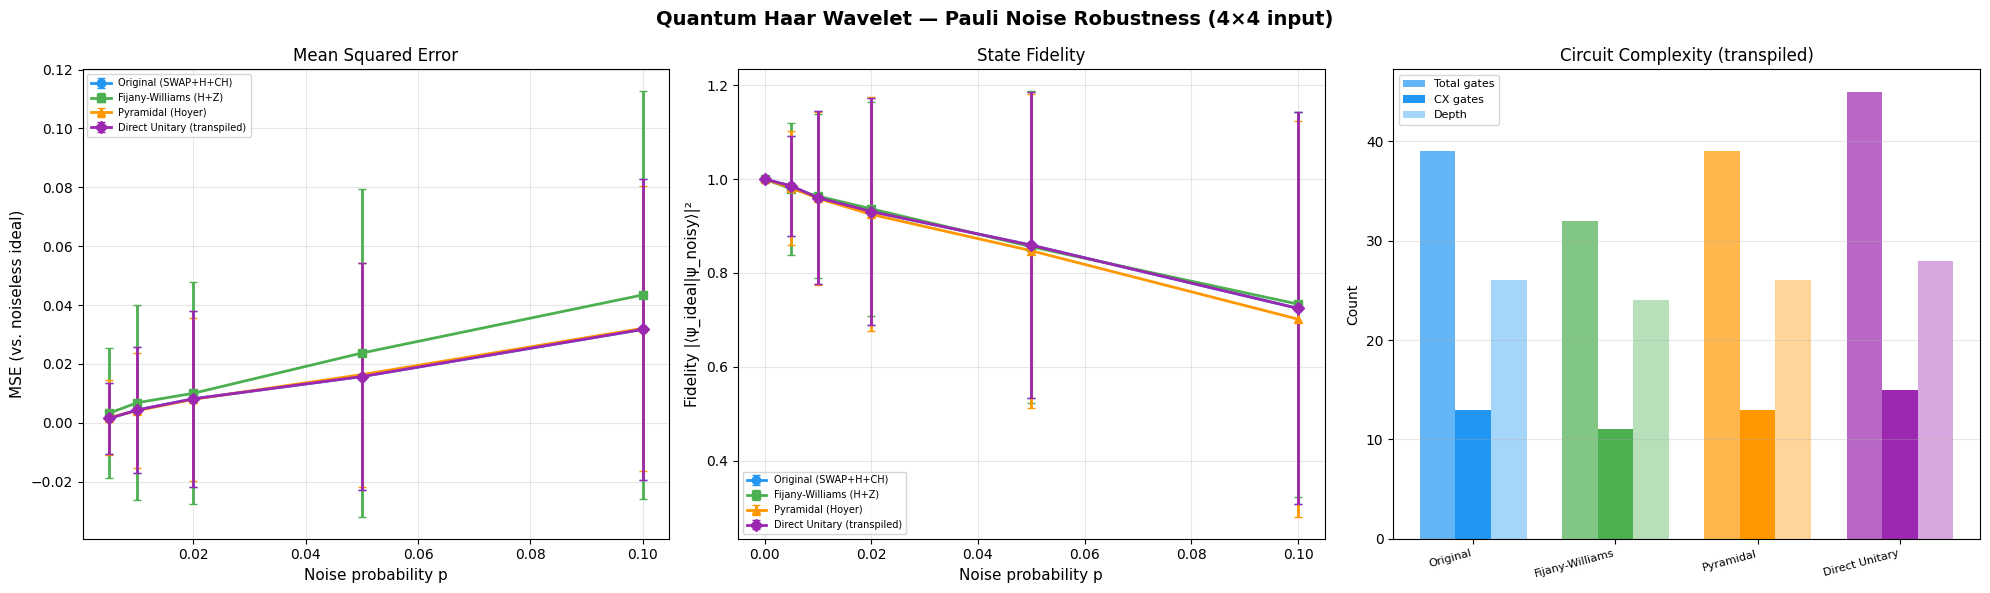

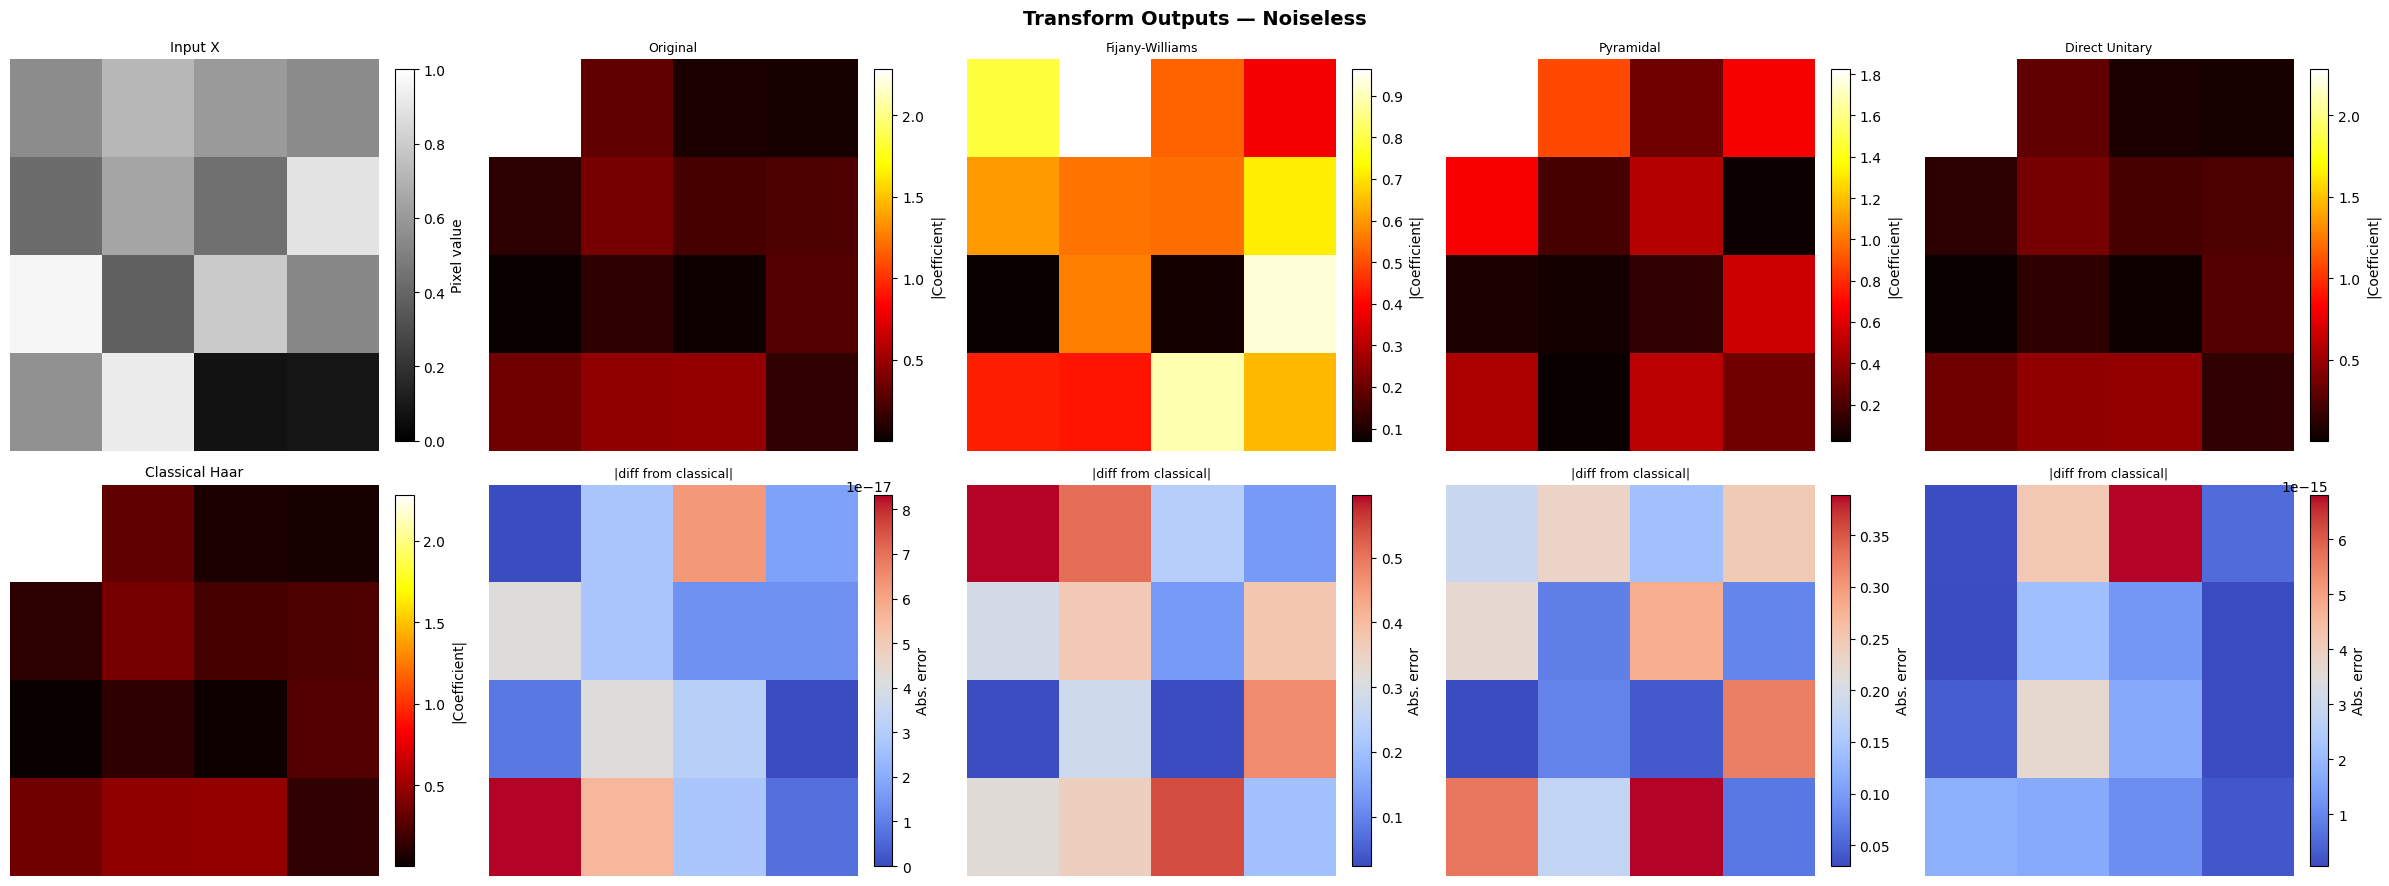

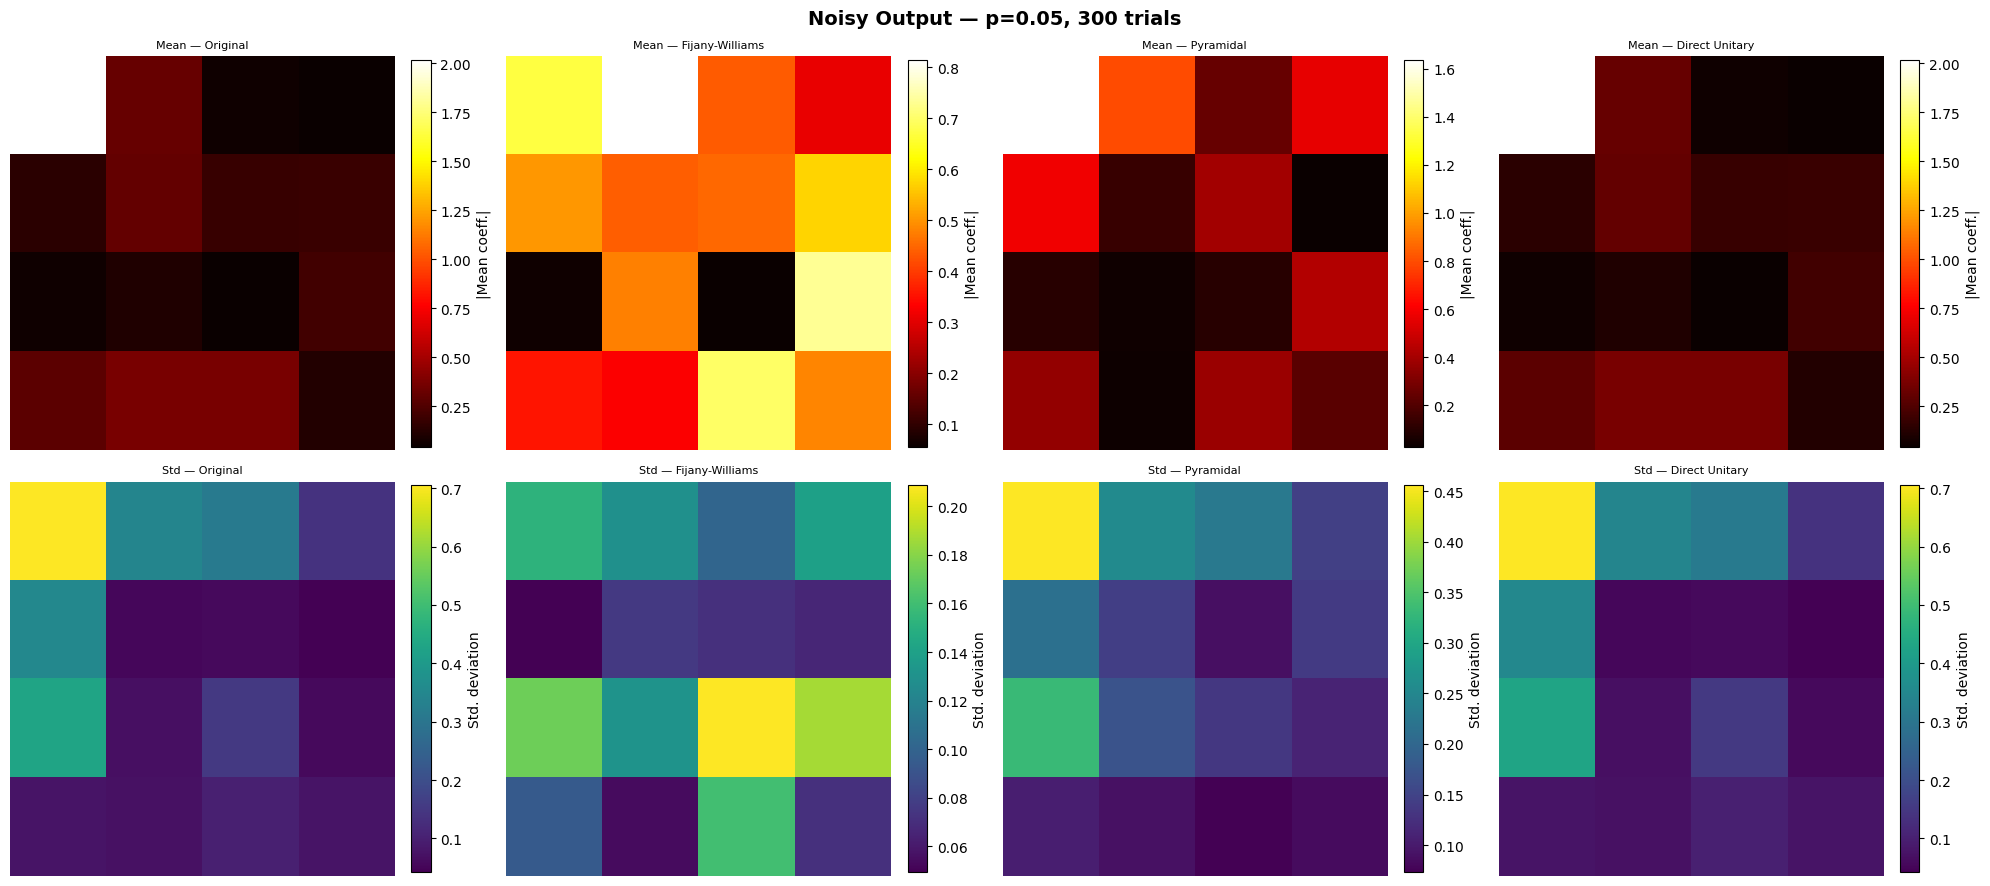

In [70]:
np.random.seed(0)
X = np.random.rand(4, 4).astype(float)

print("Input image X (4×4):")
print(np.round(X, 4))
print()

results, gate_info = compare_all(
    X,
    p_values=(0.0, 0.005, 0.01, 0.02, 0.05, 0.1),
    trials=300,
    seed=42,
)
